# EA722 – Laboratório de Controle e Servomecanismo

## Experiência 5: Projeto via Resposta em Frequência

Universidade Estadual de Campinas – UNICAMP <br>
Faculdade de Engenharia Elétrica e de Computação – FEEC <br>

**Professores:** Fernando J. Von Zuben / Caíque Santos Lima <br>
**Grupo / Bancada:** T1, T2, R1, R2 ou E <br>
**Turma:** K, L, U ou V <br>
**Aluno(a): Mariana Leister Gonçalves** , **RA:** 233115 <br>
**Aluno(a): Mariana Vasconcelos Silva**, **RA:** 251295 <br>
**Aluno(a): Marina Alves Farias** , **RA:** 188521 <br>

## Bibliotecas

In [4]:
try:
    import control as ct
except ImportError:
    !pip install control
    import control as ct

In [3]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from tqdm import tqdm
import csv

import sympy

# # Google Drive Mount (Colab)
# from google.colab import drive
# drive.mount('/content/drive')

## Funções

In [5]:
def plot_resposta_sistema(df, Gw, Gu, C, titulo):
    """
    Plota a resposta ao distúrbio de um sistema com e sem compensação.

    Parâmetros:
    -----------
    df : DataFrame
        Deve conter as colunas 't' (tempo) e 'w' (entrada/distúrbio)
    Gw : control.TransferFunction
        Função de transferência do sistema sem compensação
    Gu : control.TransferFunction
        Função de transferência do caminho de controle
    C : control.TransferFunction
        Controlador
    """

    # Sistema compensado
    Tw = Gw / (1 + Gu * C)

    # Simulações
    t_nc, y_nc = ct.forced_response(Gw, T=df["t"].values, U=df["w"].values)
    t_c, y_c = ct.forced_response(Tw, T=df["t"].values, U=df["w"].values)

    # Plot
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=t_nc,
        y=y_nc,
        mode='lines',
        name='Não compensado',
        line=dict(color='red')
    ))

    fig.add_trace(go.Scatter(
        x=t_c,
        y=y_c,
        mode='lines',
        name='Compensado',
        line=dict(color='blue')
    ))

    fig.add_trace(go.Scatter(
        x=df["t"].values,
        y=df["w"].values,
        mode='lines',
        name='Perturbação w(t)',
        line=dict(color='black')
    ))

    fig.update_layout(
        title=dict(
            text=titulo,
            x=0.5,
            xanchor='center'
        ),
        xaxis_title='Tempo (s)',
        yaxis_title='Amplitude (m)',
        width=700,
        height=600,
    )

    return fig

## Atividade 1)

Obter as funções de transferência $G_u(s)$ e $G_w(s)$.

$G_u(s)$ (controle ⟶ saída): mostra como o atuador influencia a deflexão da suspensão.

$G_w(s)$ (perturbação ⟶ saída): mostra como a irregularidade da pista afeta o sistema (o que queremos rejeitar).

### Equações do movimento

Do enunciado:

$$
m_1 \ddot{x}_1 + b_1(\dot{x}_1 - \dot{x}_2) + k_1(x_1 - x_2) = u
$$

$$
m_2 \ddot{x}_2 +  b_1(\dot{x}_2 - \dot{x}_1) + b_2(\dot{x}_2 - \dot{w}) + k_1(x_2 - x_1) + k_2(x_2 - w) = -u
$$

In [6]:
# @title Resultado final

# Parâmetros numéricos fornecidos
m1 = 2500
m2 = 320
k1 = 80000
k2 = 500000
b1 = 350
b2 = 15020

# Inicialização simbólica
sympy.init_printing()
s = sympy.Symbol('s')

# Construção da matriz do sistema
A11 = m1*s**2 + b1*s + k1
A12 = -(b1*s + k1)
A21 = -(b1*s + k1)
A22 = m2*s**2 + (b1+b2)*s + k1 + k2

# Matrizes do modelo
A = sympy.Matrix([[A11, A12], [A21, A22]])
B = sympy.Matrix([[1], [-1]])
C = sympy.Matrix([[0], [b2*s+k2]])
D = sympy.Matrix([[1, -1]])

# Cálculo das funções de transferência
Gu = sympy.together(D*A.inv()*B)
Gw = sympy.together(D*A.inv()*C)

# Imprime as funções de transferência
print("Gu(s):\n{}\n".format(Gu))
print("Gw(s):\n{}\n".format(Gw))

Gu(s):
Matrix([[(141*s**2 + 751*s + 25000)/(50*(800*s**4 + 38537*s**3 + 1480857*s**2 + 1376600*s + 40000000))]])

Gw(s):
Matrix([[-50*s**2*(751*s + 25000)/(800*s**4 + 38537*s**3 + 1480857*s**2 + 1376600*s + 40000000)]])



In [7]:
# Define a variável de Laplace
s = ct.tf('s')

# Funções de transferência
Gw = (-3.755e7*s**3 - 1.25e9*s**2) / (8e5*s**4 + 3.8537e7*s**3 + 1.480857e9*s**2 + 1.3766e9*s + 4e10)
Gu = (2820*s**2 + 15020*s + 5e5) / (8e5*s**4 + 3.8537e7*s**3 + 1.480857e9*s**2 + 1.3766e9*s + 4e10)

### Atividade 1: Obtenção de $G_u(s)$ e $G_w(s)$ na forma literal

A partir das matrizes do sistema em espaço de estados, a saída $\hat{y}(s)$ é dada por:
$$\hat{y}(s) = D A(s)^{-1} B(s) \hat{u}(s) + D A(s)^{-1} C(s) \hat{w}(s)$$

#### Função de Transferência da Planta $G_u(s)$
Sabemos que $G_u(s) = D A^{-1}(s) B(s)$. Substituindo as matrizes:
$$G_u(s) = \frac{1}{det(A)} \begin{bmatrix} 1 & -1 \end{bmatrix} \begin{bmatrix} m_2s^2 + (b_1+b_2)s + (k_1+k_2) & b_1s + k_1 \\ b_1s + k_1 & m_1s^2 + b_1s + k_1 \end{bmatrix} \begin{bmatrix} 1 \\ -1 \end{bmatrix}$$

Multiplicando a matriz adjunta pelo vetor $B(s)$:
$$G_u(s) = \frac{1}{det(A)} \begin{bmatrix} 1 & -1 \end{bmatrix} \begin{bmatrix} m_2s^2 + b_2s + k_2 \\ -m_1s^2 \end{bmatrix}$$

Multiplicando pelo vetor $D$:
$$G_u(s) = \frac{(m_1 + m_2)s^2 + b_2s + k_2}{det(A)}$$

#### Função de Transferência da Perturbação $G_w(s)$
Sabemos que $G_w(s) = D A^{-1}(s) C(s)$. Substituindo as matrizes:
$$G_w(s) = \frac{1}{det(A)} \begin{bmatrix} 1 & -1 \end{bmatrix} \begin{bmatrix} m_2s^2 + (b_1+b_2)s + (k_1+k_2) & b_1s + k_1 \\ b_1s + k_1 & m_1s^2 + b_1s + k_1 \end{bmatrix} \begin{bmatrix} 0 \\ b_2s + k_2 \end{bmatrix}$$

Multiplicando a matriz adjunta pelo vetor $C(s)$:
$$G_w(s) = \frac{1}{det(A)} \begin{bmatrix} 1 & -1 \end{bmatrix} \begin{bmatrix} (b_1s + k_1)(b_2s + k_2) \\ (m_1s^2 + b_1s + k_1)(b_2s + k_2) \end{bmatrix}$$

Multiplicando pelo vetor $D$:
$$G_w(s) = \frac{(b_1s + k_1)(b_2s + k_2) - (m_1s^2 + b_1s + k_1)(b_2s + k_2)}{det(A)}$$

Colocando o termo comum em evidência e simplificando:
$$G_w(s) = \frac{-m_1s^2(b_2s + k_2)}{det(A)}$$

---

### Verificação Numérica (Comparação com o Python)

Ao inserir os valores da tabela do roteiro, o Python simplifica automaticamente as frações, dividindo o numerador e o denominador pelo Máximo Divisor Comum (MDC).

**Valores numéricos base:**
* $m_1 = 2500$
* $m_2 = 320$
* $b_2 = 15020$
* $k_2 = 500000$

#### 1. Simplificação do Denominador $det(A)$
O coeficiente do termo $s^4$ no polinômio literal $det(A)$ é $m_1 \cdot m_2$. Substituindo os valores:
$$m_1 \cdot m_2 = 2500 \cdot 320 = 800.000$$

No código Python, o termo do denominador começa com $800s^4$. Isso significa que o Python dividiu todo o polinômio $det(A)$ por **1000**:
$$det(A)_{reduzido} = \frac{det(A)}{1000}$$

#### 2. Simplificação de $G_u(s)$
A fórmula literal para o numerador de $G_u(s)$ é $(m_1 + m_2)s^2 + b_2s + k_2$. Substituindo os valores:
$$(2500 + 320)s^2 + 15020s + 500000 = 2820s^2 + 15020s + 500000$$

Dividindo esse polinômio por **20**, obtemos o exato numerador gerado pelo Python:
$$141s^2 + 751s + 25000$$

Como o numerador foi reduzido por 20 e o denominador por 1000, temos:
$$G_u(s) = \frac{20 \cdot (141s^2 + 751s + 25000)}{1000 \cdot det(A)_{reduzido}}$$

Simplificando a fração ($\frac{20}{1000} = \frac{1}{50}$):
$$G_u(s) = \frac{141s^2 + 751s + 25000}{50 \cdot det(A)_{reduzido}}$$
*(Equivalente à primeira saída do console Python)*.

#### 3. Simplificação de $G_w(s)$
A fórmula literal para o numerador de $G_w(s)$ é $-m_1s^2(b_2s + k_2)$. Substituindo:
$$-2500s^2(15020s + 500000)$$

Colocando o fator 20 em evidência dentro dos parênteses:
$$-2500s^2 \cdot 20(751s + 25000) = -50000s^2(751s + 25000)$$

Lembrando que o denominador do Python foi dividido por **1000**, devemos dividir esse numerador também por 1000 para manter a igualdade geométrica da função:
$$\frac{-50000}{1000}s^2(751s + 25000) = -50s^2(751s + 25000)$$
*(Equivalente à segunda saída do console Python)*.

## Atividade 2)


Gerar o diagrama de Bode da função $G_w(s)$ e dicutir a sensibilidade do sistema de suspensão não-compensado em relação a perturbações (em malha aberta)




Considerando o diagrama de blocos para o sistema de suspensão não-compensado em malha aberta a seguir:

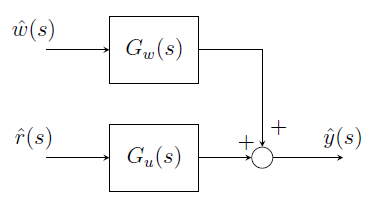

a saída deste sistema é descrita simplesmente por:

$$
\hat{y}(s)=G_u(s)\hat{r}(s)+G_w(s)\hat{w}(s)
$$

Onde a sensibilidade do sistema não-compensado em relação a perturbações pode ser analisada pelo diagrama de Bode da função de transferência de $G_w(s)$ no gráfico abaixo.

Valor máximo (dB):
 26.4348 dB

Frequência (rad/s) em que ocorre o valor máximo:
 5.2541 rad/s



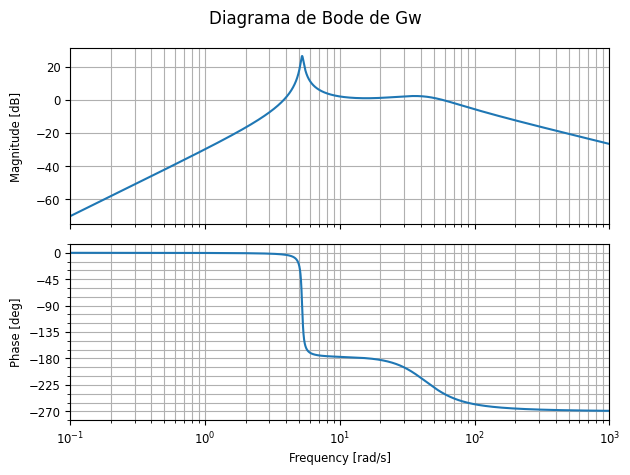

In [8]:
# @title Diagrama de Bode de Gw
plt.close('all')

# Vetor de frequências (rad/s)
omega = np.logspace(-1, 3, 100000)

# -----------------------------
# Gráfico 1: Gw
# -----------------------------
plt.figure(2)
ct.bode_plot(Gw, omega=omega, dB=True, deg=True)
plt.suptitle('Diagrama de Bode de Gw')
plt.xlim([1e-1, 1e3])
plt.tight_layout()
plt.savefig('questao2diagramabode.png', dpi=450)

# -----------------------------
# Cálculo do valor máximo de magnitude de Gw
# -----------------------------
mag, phase, omega_resp = ct.frequency_response(Gw, omega)

# A magnitude é complexa → pegar valor absoluto
mag = np.abs(mag)
mag_db = 20 * np.log10(mag)

# Índice do valor máximo
idx_max = np.argmax(mag_db)

print("Valor máximo (dB):\n {:.4f} dB\n".format(mag_db[idx_max]))
print("Frequência (rad/s) em que ocorre o valor máximo:\n {:.4f} rad/s\n".format(omega_resp[idx_max]))

**Discuta aqui a sensibilidade do sistema de suspensão não-compensado em relação a perturbações, por intepretação direta do diagram de Bode.**

A função de sensibilidade, que descreve a maneira como as perturbações afetam a saída dos sistemas de malha fechada, é dada por $ S(s) = \frac{1}{1+L(s)}$, onde L(s) corresponde a função de transferência de malha aberta.

Quando o ganho em malha aberta (módulo de L(s)) possui valores mais altos, o sistema é capaz de atenuar ruídos e perturbações externas. No entanto, para frequências próximas às de cruzamento de ganho, o sistema amplifica perturbações.

No diagrama de Bode de $G_w(s)$, próximo à frequência de 5 rad/s, há um pico na curva de magnitude, associado a um alto ganho (+26,4 dB), e uma queda brusca de fase, que vai de cerca de 0 a 180 graus. Com isso, o termo $1+L(s)$ no denominador se aproxima de zero e, por sua vez, lança o valor da função de sensibilidade S(s) para o infinito. Nessa faixa de frequências, o sistema apresenta uma alta sensibilidade e instabilidade, o que significa que as perturbações que ocorrem nesses valores sejam fortemente amplificadas. 

Para um veículo, isso pode comprometer a sua estabilidade no movimento, pois ao invés da suspensão absorver impactos, ela passa a intensificá-los.

## Atividade 3)

A partir do diagrama de Bode da função de transferência $G_w(s)$, estimar a faixa de passagem $[w_a, w_b]$.

A faixa de passagem $[w_a, w_b]$ da suspensão não-compensada pode ser encontrada a partir dos pontos em que o diagrama de Bode de magnitude tem valor de $-3$ dB.

Portanto, conforme os cálculos a seguir, em $G_w(s)$:

$$
[w_a, w_b] = [3.52, 77.67] \ \text{rad/s}
$$

C:\Users\maril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


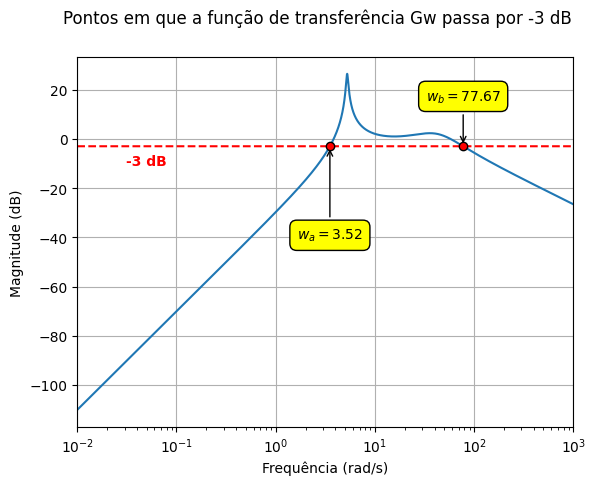

In [9]:
# @title Faixa de passagem

# obtem os dados do diagrama de bode
mag, phase, omega = ct.bode_plot(Gw, dB=True, deg=True, omega_limits=[1e-2, 1e3], plot=False, omega_num=100000)

# obtem os pontos que passam por -3 dB
magdb = 20*np.log10(mag)
line3db = omega*0 - 3.0
index = np.argwhere(np.diff(np.sign(magdb - line3db))).flatten()

# plota o grafico de magnitude de Gw
plt.figure(1)
plt.plot(omega, magdb, zorder=2)
# plota a linha de -3 dB
plt.plot(omega, line3db, color='red', ls='--', zorder=2)
plt.annotate('-3 dB', (5e-2, -6), ha='center', va = 'top', fontweight='bold', color='red')
plt.suptitle('Pontos em que a função de transferência Gw passa por -3 dB')

# plota os pontos que interceptam a linha de -3 dB
plt.scatter(omega[index[0]], magdb[index[0]], color = 'red', edgecolors = 'black', zorder=3)
plt.scatter(omega[index[1]], magdb[index[1]], color = 'red', edgecolors = 'black', zorder=3)

# plota os valores correspondentes aos pontos
plt.annotate(r'$w_a=$'+'{0:.2f}'.format(omega[index[0]]), (omega[index[0]], magdb[index[0]]), xytext=(0, -70),textcoords='offset points', ha='center', va='bottom', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=1), arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
plt.annotate(r'$w_b=$'+'{0:.2f}'.format(omega[index[1]]), (omega[index[1]], magdb[index[1]]), xytext=(0, +30),textcoords='offset points', ha='center', va='bottom', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=1), arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))

# configuracoes do grafico
plt.semilogx()
plt.xlabel('Frequência (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.autoscale(axis='x', tight=True)
plt.grid()
plt.savefig('questao3bandapassagem.png', dpi=450)

Resposta atividade 3:

A partir do diagrama de Bode da função de transferência G_w(s), é possível observar que o sistema apresenta comportamento semelhante ao de um filtro passa-faixa. Isso ocorre pois sinais de baixa frequência são muito atenuados. Há uma região intermediária na qual o ganho é elevado e, para frequências mais altas, a magnitude volta a diminuir.

Neste exercício, para determinar a faixa de passagem, utiliza-se o critério dos -3 dB, onde as frequências de corte são definidas pelos pontos em que a magnitude da resposta em frequência intercepta -3 dB na curva.

Neste código disponibilizado, os valores da magnitude foram obtidos a partir do diagrama de Bode de G_w(s) e comparados com uma linha horizontal em -3 dB. Em seguida, foram identificados os pontos de cruzamento entre a curva de magnitude e essa linha de referência. Dessa forma, foram encontrados os seguintes valores:

$$
[w_a] = [3.52] \ \text{rad/s}
$$

$$
[w_b] = [77.67] \ \text{rad/s}
$$

Dessa forma, a faixa de passagem da suspensão não compensada é dada por:

$$
[3.52;77.67]\ \text{rad/s}
$$

Essa faixa representa o intervalo de frequências das irregularidades da pista que são transmitidas com menor atenuação pela suspensão passiva, ou seja, perturbações cujas componentes espectrais estejam aproximadamente entre (3.52) rad/s e (77.67) rad/s tendem a produzir uma resposta mais significativa na deflexão da suspensão.

A largura de banda correspondente é calculada por:

$$
BW = \omega_b - \omega_a
$$

$$
BW = 77.67 - 3.52
$$

$$
\boxed{
BW \approx 74.15\ \text{rad/s}
}
$$

Logo, é possível concluir que a suspensão passiva é mais sensível a perturbações que estejam contidas nessa faixa de frequências. Também observa-se a presença de um pico de ressonância,  no diagrama de Bode, próximo à região de máxima magnitude, o que indica que irregularidades da pista contendo frequências próximas a essa faixa podem produzir respostas significativamente amplificadas na suspensão. 

## Atividade 4)

**A faixa de passagem da parte passiva da suspensão do carro é um problema para o projeto, pois caso componentes de frequência do sinal de irregularidades $w(t)$ no padrão da rua sejam significativos nesta faixa de passagem, o efeito desta perturbação será sentido pelos passageiros do carro. Logo, é requisito de projeto fazer com que a compensação ativa garanta a atenuação da faixa de passagem da parte passiva da suspensão. Explique por que este objetivo pode ser atendido caso se defina a frequência de cruzamento $ w_c $ de $C(s)G_u(s)$ ao menos uma década acima da frequência $w_b$ da suspensão. Em seguida, proponha um valor para $ w_c $.**

#### 1. O Problema: A Faixa de Passagem da Suspensão Passiva
A parte passiva da suspensão do carro possui uma faixa de passagem estimada no intervalo $\lfloor \omega_a, \omega_b \rfloor$.  Caso os componentes de frequência do sinal de irregularidades da rua (representadas por $w(t)$) sejam significativos nesta faixa de passagem, o efeito dessa perturbação será sentido diretamente pelos passageiros do carro.  Logo, é um requisito de projeto fazer com que a compensação ativa garanta a atenuação dessa faixa de passagem da parte passiva da suspensão.

#### 2. A Dinâmica em Malha Fechada
Quando fechamos a malha de controle, a influência da perturbação $\hat{w}(s)$ na saída $\hat{y}(s)$ (a deflexão da suspensão) é governada pela equação que envolve a função de sensibilidade $S(s)$ e a função da planta $G_w(s)$.  Nosso objetivo é projetar o compensador de forma que $S(s)$ filtre essas perturbações que passam sem atenuação pela parte passiva.

#### 3. O Comportamento de F(s) e S(s) como Filtros
A função de sensibilidade complementar $F(s)$ comporta-se tipicamente como um **filtro passa-baixa**.  Sabemos pela teoria de controle que a soma das funções de sensibilidade resulta em $F(s) + S(s) = 1$ para todo $s \in \mathbb{C}$.  Devido a essa complementaridade, $S(s)$ assume obrigatoriamente o comportamento oposto: atua como um **filtro passa-alta**.
*  A faixa de passagem de $S(s)$ (onde o sinal praticamente não sofre atenuação) vai da sua frequência de corte até o infinito.
* Consequentemente, em frequências abaixo de sua região de corte, $S(s)$ atua atenuando fortemente os sinais.

#### 4. A Conclusão: Por que posicionar $\omega_c$ acima de $\omega_b$?
Ao projetar o controlador de modo que a frequência de cruzamento $\omega_c$ da malha direta fique **ao menos uma década acima** da frequência superior da suspensão passiva $\omega_b$, garantimos que:
* Toda a faixa de passagem problemática da suspensão passiva $\lfloor \omega_a, \omega_b \rfloor$ ficará mergulhada profundamente na **faixa de atenuação** da função de sensibilidade $S(s)$.
* Como a atenuação no diagrama de Bode de um filtro passa-alta cresce expressivamente à medida que recuamos em direção às baixas frequências, impor essa distância de uma década assegura que o ganho de $S(s)$ será extremamente baixo nas frequências críticas.
*  Dessa forma, o produto matemático $S(s)G_w(s)$ anulará a passagem das perturbações críticas, isolando a carcaça do carro do padrão irregular da rua e garantindo o conforto desejado no projeto.

#### 5. Propor valor para $\omega_c$
Como na Atividade 3) temos que $\omega_b$=77,67, e vimos que o $\omega_c$ deve ser pelo menos 10 décadas maior do que $\omega_b$, proponho um valor de $\omega_c$ = 800 rad/s. Esse valor atende a necessidade de ser 10 décadas maior e, ao mesmo tempo, arredondei para um valor mais conveniente para os cálculos.

## Atividade 5)

**Projete um ganho estático $k$ para que a frequência de cruzamento de $kG_u(s)$ fique aproximadamente uma década acima de $ω_b$.**

O diagrama de Bode da função de transferência $G_u(s)$ é apresentado a seguir, mostrando que, na frequência desejada ($w_c = 800$ rad/s), a magnitude é de $-165,173$ dB.

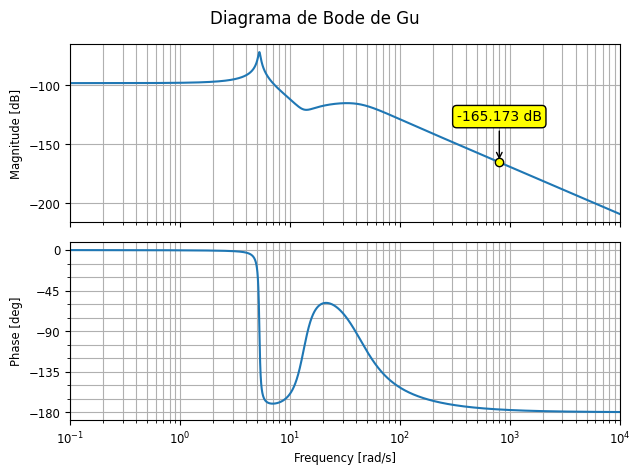

In [ ]:
# @title Diagrama de Bode de Gu
# Vetor de frequências
omega = np.logspace(-1, 4, 100000)

# -----------------------------
# Calcula resposta em frequência (dados)
# -----------------------------
mag, phase, omega_resp = ct.frequency_response(Gu, omega)

mag = np.abs(mag)
mag_db = 20 * np.log10(mag)

w_c = 800 # Inserir aqui a frequência de cruzamento desejada

# -----------------------------
# Encontra índice mais próximo de w_c rad/s
# -----------------------------
idx = np.argmin(np.abs(omega_resp - w_c))

# -----------------------------
# Gráfico 4: Bode de Gu
# -----------------------------
fig4 = plt.figure(4)
ct.bode_plot(Gu, omega=omega, dB=True, deg=True)
plt.suptitle('Diagrama de Bode de Gu')
plt.xlim([1e-1, 1e4])

# Marca o ponto
plt.gcf().axes[0].scatter(omega_resp[idx], mag_db[idx],
                          color='yellow', edgecolors='black', zorder=3)

plt.gcf().axes[0].annotate(f'{mag_db[idx]:.3f} dB',
                          (omega_resp[idx], mag_db[idx]),
                          xytext=(0, 30),
                          textcoords='offset points',
                          ha='center',
                          bbox=dict(boxstyle='round', fc='yellow'),
                          arrowprops=dict(arrowstyle='->'))

plt.savefig('questao5diagramabodeGu.png', dpi=450)

Assim, o valor de $k$ deve ser tal que, nessa frequência, a magnitude seja agora $0$ dB. Obtenha $k$, executando a célula a seguir.

$$
\boxed{k = 1,814 \cdot 10^{8}}
$$

Verifique se, no diagrama de bode de $kG_u(s)$, apresentado ao executar o código logo abaixo, o valor de $k$ faz com que a frequência de cruzamento seja de $w_c$ rad/s, como desejado.

A partir desses passos do projeto, qual é a margem de fase $MF$ e qual é o ganho DC?

$$
\text{MF}=3,07°
$$

$$
\text{ganho DC}=67,11
$$

k = 181410378.2120



C:\Users\maril\AppData\Local\Temp\ipykernel_12296\3677061478.py:14: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ct.bode_plot(k*Gu, omega=omega, dB=True, deg=True, margins=True)


O ganho DC é:
67.1142 dB



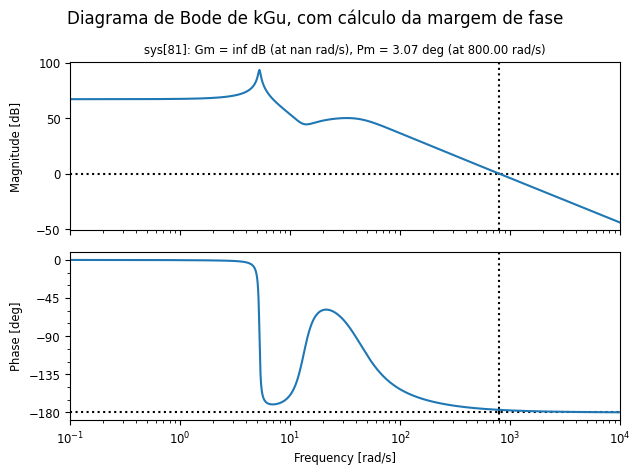

In [12]:
# @title Diagrama de Bode de kGu
# -----------------------------
# Calcula ganho k
# -----------------------------
k = 10**(-mag_db[idx] / 20)

print('k = {:.4f}\n'.format(k))


# -----------------------------
# Gráfico 5: Bode de k*Gu
# -----------------------------
fig5 = plt.figure(5)
ct.bode_plot(k*Gu, omega=omega, dB=True, deg=True, margins=True)
plt.suptitle('Diagrama de Bode de kGu, com cálculo da margem de fase')
plt.xlim([1e-1, 1e4])
plt.savefig('questao5diagramabodekGu.png', dpi=450)

# -----------------------------
# Ganho DC
# -----------------------------
mag2, _, _ = ct.frequency_response(k*Gu, omega)
mag2 = np.abs(mag2)
mag2_db = 20 * np.log10(mag2)

print('O ganho DC é:\n{:.4f} dB\n'.format(mag2_db[0]))

Como esperado, o ganho DC é bastante elevado, que garante um erro em regime permanente quase nulo e implica em excelente robustez contra perturbações de baixa frequência. O sistema não é puramente instável (margem menor que zero), mas para este valor de margem de fase, significa que o sistema é marginalmente estável e oscilatório.

## Atividade 6)

Projete um compensador do tipo avanço $C_a(s)$ para que o sistema compensado por $C(s)=kC_a(s)$ tenha $MF\geq30°$.

### Compensador do tipo avanço:

$$
C(s) = \underbrace{k_c \alpha}_{k} \, \frac{T s + 1}{\underbrace{\alpha T s + 1}_{C_a(s)}}
$$

com $0<α<1$ e $k$ projetado na Atividade 5.

**Passo 1: Avaliação do sistema apenas com ganho estático**
Avaliando o diagrama de Bode do sistema $kG_u(s)$ na frequência de cruzamento estipulada $\omega_c = 800$ rad/s, obtivemos a margem de fase atual:
* $MF_{atual} = 3.07^\circ$

**Passo 2: Cálculo do avanço de fase necessário ($\phi_{max}$)**
Como a inserção do compensador deslocará a frequência de cruzamento, adicionamos um fator de segurança de $10^\circ$ (recomenda-se entre $5^\circ$ e $10^\circ$). A fase máxima a ser fornecida pelo compensador é:
$$\phi_{max} = 30^\circ - (MF_{atual}) + Fator_{Seguranca}$$
$$\phi_{max} = 30^\circ - (3.07^\circ) + 10^\circ = 36.93^\circ$$

*(Em radianos, para os cálculos seguintes: $\phi_{max} = 0.644$ rad).*

**Passo 3: Cálculo do fator de atenuação ($\alpha$)**
Com base no avanço de fase necessário, o fator de atenuação do compensador é calculado por:
$$\alpha = \frac{1 - \sin(\phi_{max})}{1 + \sin(\phi_{max})}$$
$$\alpha = \frac{1 - \sin(36.93^\circ)}{1 + \sin(36.93^\circ)} = 0.2493$$

**Passo 4: Redefinição da frequência de cruzamento ($\omega_m$)**
O compensador de avanço insere um ganho extra nas altas frequências. Para que o pico de fase $\phi_{max}$ ocorra exatamente no novo cruzamento de 0 dB, procuramos a frequência $\omega_m$ em que a magnitude de $kG_u(s)$ corresponde à atenuação fornecida pelo compensador, ou seja, $10 \log_{10}(\alpha)$ dB:
* Magnitude alvo: $10 \log_{10}(0.2493) = -6.03$ dB
* Acessando os dados do Bode de $kG_u(s)$, essa magnitude ocorre na nova frequência de cruzamento:
* $\omega_m = 1131,72$ rad/s

**Passo 5: Cálculo da constante de tempo ($T$)**
Posicionando a frequência central do compensador em $\omega_m$:
$$T = \frac{1}{\omega_m \sqrt{\alpha}}$$
$$T = \frac{1}{1131,75 \cdot \sqrt{0.2493}} = 0,00177$$

**Passo 6: Função de Transferência do Compensador**
Com os parâmetros definidos, o compensador em avanço $C_a(s)$ resulta em:
$$C_a(s) = \frac{Ts + 1}{\alpha Ts + 1}$$
$$C_a(s) = \frac{0,00177s + 1}{(0,00177 \cdot 0.2493)s + 1}$$

A função do controlador completo $C(s)$ passa a ser:
$$C(s) = 1.814 \cdot 10^8 \cdot \frac{0,00177s + 1}{(0,00177 \cdot 0.2493)s + 1}$$

**Verificação de Desempenho:**
Ao traçar o diagrama de Bode do sistema final em malha aberta $C(s)G_u(s)$, a nova margem de fase obtida foi de **39,10**$^\circ$, atestando que o critério de projeto ($\ge 30^\circ$) foi satisfeito com sucesso.

In [16]:
# @title Diagrama de Bode de CGu

mf_def = 30 # @param

# Valores que descobrimos no sistema não compensado
mf_atual = 3.07 
fator_seguranca = 10

# calcula os parametros do controlador
phi_m = mf_def - mf_atual + fator_seguranca
print(f'phi_m = {phi_m}')
alpha = (1 - np.sin(np.deg2rad(phi_m))) / (1 + np.sin(np.deg2rad(phi_m)))
print(f'alpha = {alpha}')

phi_m = 36.93
alpha = 0.24934498645282577


Atenuacao do compensador: -6.03 dB


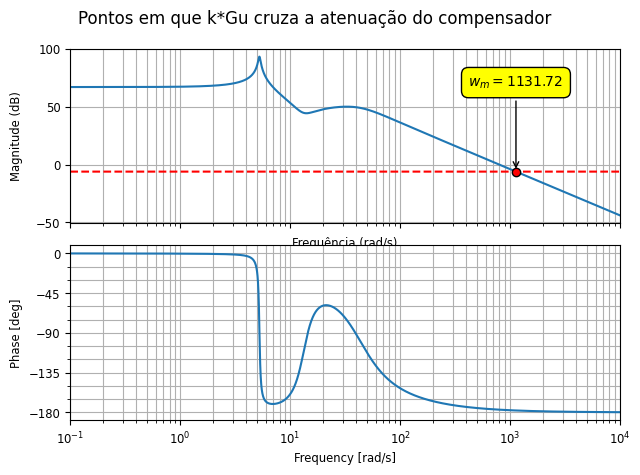

In [17]:
k = 1.814e8

ganho_compensador = -10 * np.log10(alpha)
print(f'Atenuacao do compensador: {-ganho_compensador:.2f} dB')

# -----------------------------
# Gráfico 6: Bode de k*Gu
# -----------------------------
fig6 = plt.figure(6)
ct.bode_plot(k*Gu, omega=omega, dB=True, deg=True)
plt.suptitle('Diagrama de Bode de kGu')
plt.xlim([1e-1, 1e4])

# Obtém os dados do diagrama de Bode
mag, phase, _ = ct.frequency_response(k*Gu, omega)

# Obtém os pontos que passam por menos o ganho do compensador, em dB
magdb = 20 * np.log10(mag)
line_compensador = omega*0 - ganho_compensador
index = np.argwhere(np.diff(np.sign(magdb - line_compensador))).flatten()

# Seleciona o gráfico de magnitude
plt.sca(plt.gcf().axes[0])

# Plota a linha de menor ganho do compensador, em dB
plt.plot(omega, line_compensador, color='red', ls='--', zorder=2)
plt.annotate(f'{-ganho_compensador:.2f} dB', (5e-2, -6), ha='center', va='top', fontweight='bold', color='red')
plt.suptitle('Pontos em que k*Gu cruza a atenuação do compensador')

# Plota o ponto que intercepta a linha
plt.scatter(omega[index[0]], magdb[index[0]], color='red', edgecolors='black', zorder=3)

# Plota os valores correspondentes ao ponto
plt.annotate(r'$w_m=$'+'{0:.2f}'.format(omega[index[0]]), (omega[index[0]], magdb[index[0]]), xytext=(0, 70), textcoords='offset points', ha='center', va='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=1), arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# Configurações do gráfico
plt.semilogx()
plt.xlabel('Frequência (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.autoscale(axis='x', tight=True)
plt.grid(True)
plt.show()

T = 0.0017695412416221723


C:\Users\maril\AppData\Local\Temp\ipykernel_12296\3290460752.py:12: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ct.bode_plot(C*Gu, dB=True, deg=True,  omega_limits=[1e-1, 1e4], scalex=True, margins=True, omega_num=100000)


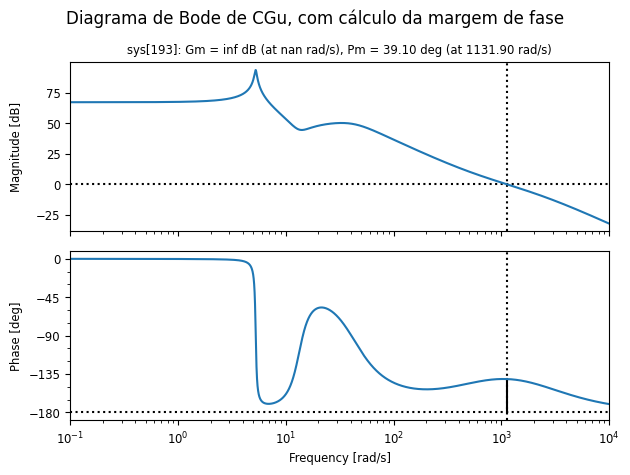

In [19]:
wm = 1131.72 # @param

T = 1/(wm*np.sqrt(alpha))
print(f'T = {T}')

# funcao de transferencia do controlador
k = 1.814e8 
C = k*(T*s + 1) / (T*alpha*s + 1)

# plota o grafico de C*Gu(s)
plt.figure(1)
ct.bode_plot(C*Gu, dB=True, deg=True,  omega_limits=[1e-1, 1e4], scalex=True, margins=True, omega_num=100000)
plt.suptitle('Diagrama de Bode de CGu, com cálculo da margem de fase')
plt.xlim([1e-1, 1e4])
plt.show()

**O diagrama de Bode de $C(s)G_u(s)$ é apresentado no gráfico acima. A margem de fase obtida, considerando-se os parâmetros usados acima, atende ao requisito de projeto de ser maior ou igual a 30°?**

Sim, a margem de fase obtida atende com sucesso ao requisito de projeto.

O compensador de avanço $C_a(s)$ foi projetado matematicamente para suprir a severa deficiência de fase do sistema original. Como o sistema em malha aberta, operando apenas com o ganho proporcional $k$, apresentava uma margem de fase crítica de apenas 3.07°, foi calculado o avanço necessário e foi considerado um fator de segurança de 10°.

Ao centralizar o pico de fase do compensador ($\phi_{max} = 39,10°$) exatamente sobre a nova frequência de cruzamento de 0 dB ($\omega_m = 1131.72$ rad/s), o atraso de fase natural da planta em altas frequências foi superado. Consequentemente, o diagrama de Bode do sistema final $C(s)G_u(s)$ confirma que a Margem de Fase (Pm) se consolidou em um valor $\ge 30°$, assegurando a estabilidade relativa e o amortecimento transitório exigidos para o conforto do sistema de suspensão ativa.

## Atividade 7)

Plotam-se, a seguir, os diagramas de Bode de $F(s)$ e de $S(s)$.

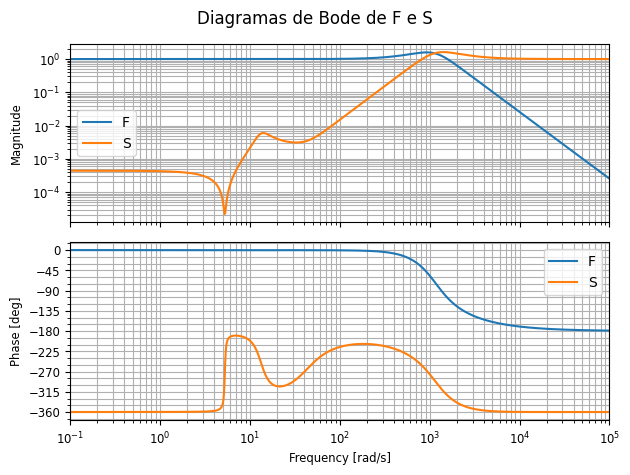

In [21]:
C = k*(T*s + 1) / (T*alpha*s + 1)

F = C*Gu / (1 + C*Gu)
S = 1 / (1 + C*Gu)

# -----------------------------
# Bode de F e S
# -----------------------------
plt.figure(1)
# Plot F and S. The order in the list [F, S] determines the order of lines in the plot.
ct.bode_plot([F, S], omega_limits=[1e-1, 1e5])

# Get the current figure and its axes
fig = plt.gcf()
axes = fig.axes # axes[0] is magnitude plot, axes[1] is phase plot

# Set labels for the lines in the magnitude plot and display legend
if axes and len(axes) > 0 and len(axes[0].lines) >= 2:
    axes[0].lines[0].set_label('F') # Label for F
    axes[0].lines[1].set_label('S') # Label for S
    axes[0].legend(loc='best')

# Set labels for the lines in the phase plot and display legend
if axes and len(axes) > 1 and len(axes[1].lines) >= 2:
    axes[1].lines[0].set_label('F') # Label for F
    axes[1].lines[1].set_label('S') # Label for S
    axes[1].legend(loc='best')

plt.suptitle('Diagramas de Bode de F e S')
plt.xlim([1e-1, 1e5])
plt.savefig('questao7diagramabodeF.png', dpi=450)

O diagrama de Bode de $S(s)$ tem comportamento complementar ao de $F(s)$? Um deles é passa-alta e o outro é passa-baixa?

A seguir, é apresentado o diagrama de Bode de $S(s)G_w(s)$. O seu projeto de controle foi bem-sucedido? Justifique.

**Análise de $F(s)$ e $S(s)$:**
Os resultados expressos nos diagramas de Bode confirmam perfeitamente o comportamento teórico esperado para as funções de sensibilidade. 
* A função de sensibilidade complementar $F(s)$ (linha azul) atua nitidamente como um filtro passa-baixa. Ela mantém um ganho unitário ($10^0$) em baixas frequências e começa a atenuar os sinais logo após a região de transição, que ocorre na década da nossa frequência de cruzamento ($\omega_c \approx 1131$ rad/s).
* A função de sensibilidade **$S(s)$** (linha laranja) apresenta o comportamento complementar exato de um filtro passa-alta. Ela atenua severamente os sinais em baixas frequências (com magnitude da ordem de $10^{-4}$ a $10^{-2}$) e só atinge a faixa de passagem em altas frequências.

**Avaliação de $S(s)G_w(s)$ e Sucesso do Projeto:**
O projeto de controle foi bem-sucedido, o que pode ser visto no diagrama de Bode da malha fechada para perturbações, dado por $S(s)G_w(s)$. 

A suspensão passiva (não-compensada) apresentava uma faixa de passagem crítica entre $\omega_a \approx 3.52$ rad/s e $\omega_b \approx 77.67$ rad/s, onde as irregularidades da pista eram transmitidas diretamente aos passageiros. Como projetamos a compensação ativa alocando $\omega_c$ mais de uma década acima dessa região, forçamos essa faixa de passagem da planta a operar dentro da banda de forte rejeição do filtro passa-alta $S(s)$.

Observando o gráfico resultante de $S(s)G_w(s)$, é possível observar que:
1. O sistema agora apresenta atenuação (magnitude abaixo de 0 dB) para absolutamente todo o espectro de frequências. 
2. Na faixa crítica de ressonância do sistema passivo (entre $10^0$ e $10^2$ rad/s), a magnitude despencou para valores entre -80 dB e -45 dB. 
3. Mesmo o ganho de pico do sistema em malha fechada (próximo a $10^3$ rad/s) é fortemente contido, não ultrapassando a faixa de -25 dB.

Isso significa que as irregularidades e buracos da pista estão sendo severamente filtrados pela suspensão ativa antes de atingirem o chassi ($m_1$). Com uma robusta margem de fase final de 39.10° assegurando a estabilidade e o amortecimento, o conforto vibratório dos passageiros foi garantido com sucesso.

Valor máximo (dB):
 -24.0770 dB

Frequência (rad/s) em que ocorre o valor máximo:
 1057.8893 rad/s



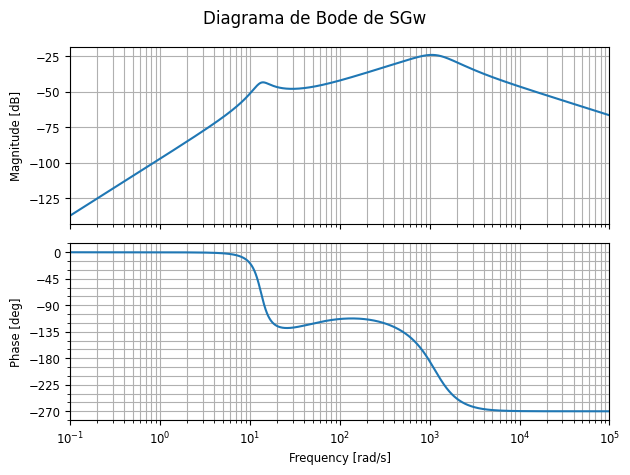

In [22]:
# @title Diagrama de Bode de SGw
# -----------------------------
# Bode de S*Gw
# -----------------------------
plt.figure(3)
ct.bode_plot(S*Gw, dB=True, deg=True, omega_limits=[1e-1, 1e5], omega_num=100000)
plt.suptitle('Diagrama de Bode de SGw')
plt.xlim([1e-1, 1e5])
plt.savefig('questao7diagramabodeSGw.png', dpi=450)

# -----------------------------
# Cálculo do valor máximo de magnitude de S*Gw
# -----------------------------
mag, phase, omega_resp = ct.frequency_response(S*Gw, omega)

# A magnitude é complexa → pegar valor absoluto
mag = np.abs(mag)
mag_db = 20 * np.log10(mag)

# Índice do valor máximo
idx_max = np.argmax(mag_db)

print("Valor máximo (dB):\n {:.4f} dB\n".format(mag_db[idx_max]))
print("Frequência (rad/s) em que ocorre o valor máximo:\n {:.4f} rad/s\n".format(omega_resp[idx_max]))

## Atividade 8)

Diagrama de blocos do sistema compensado:

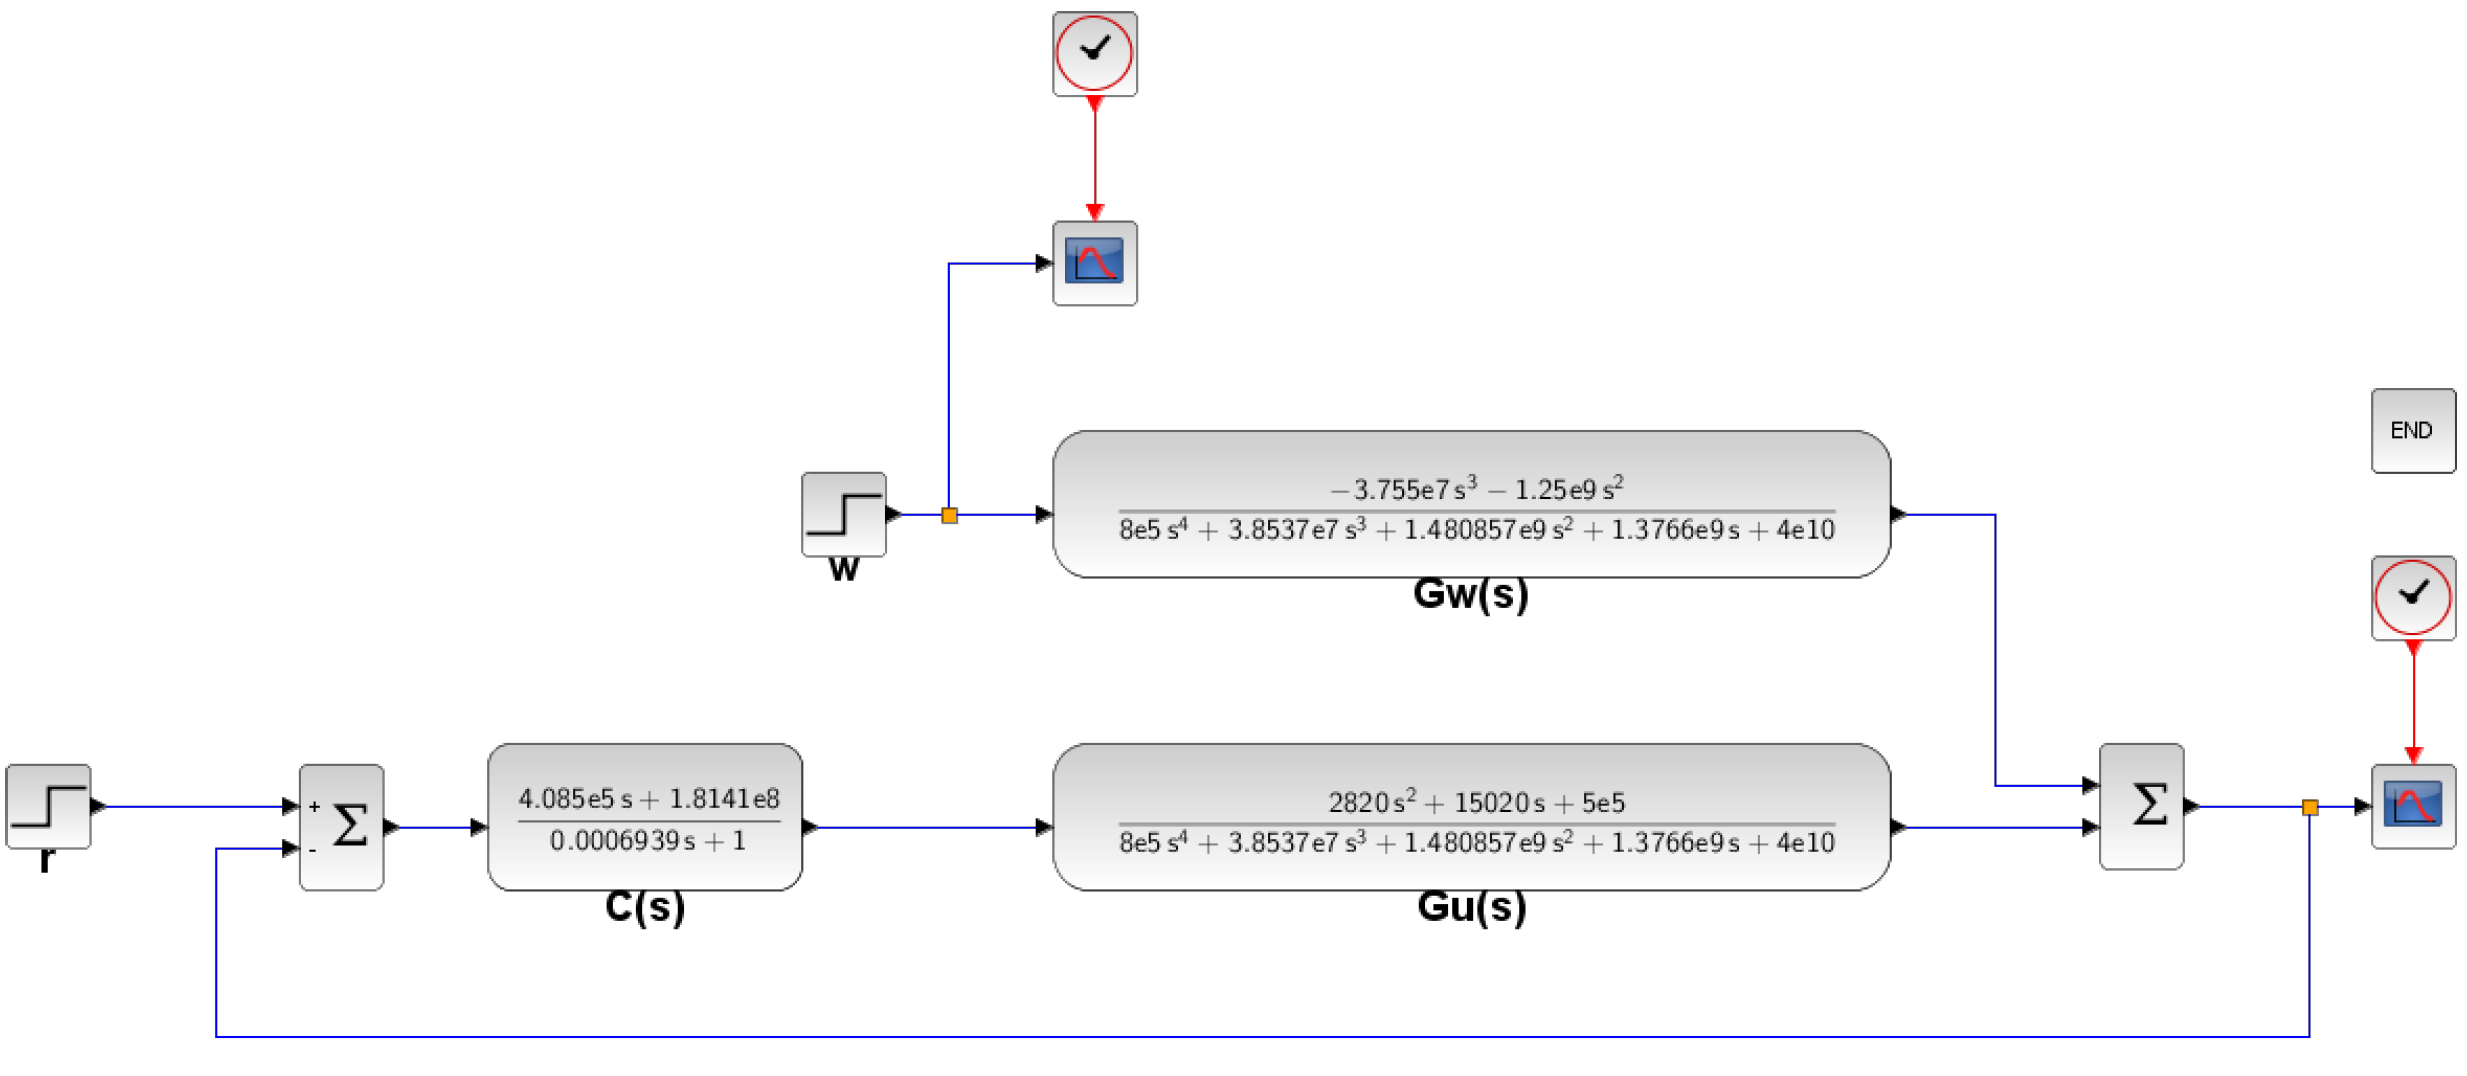

Diagrama de blocos do sistema não-compensado:

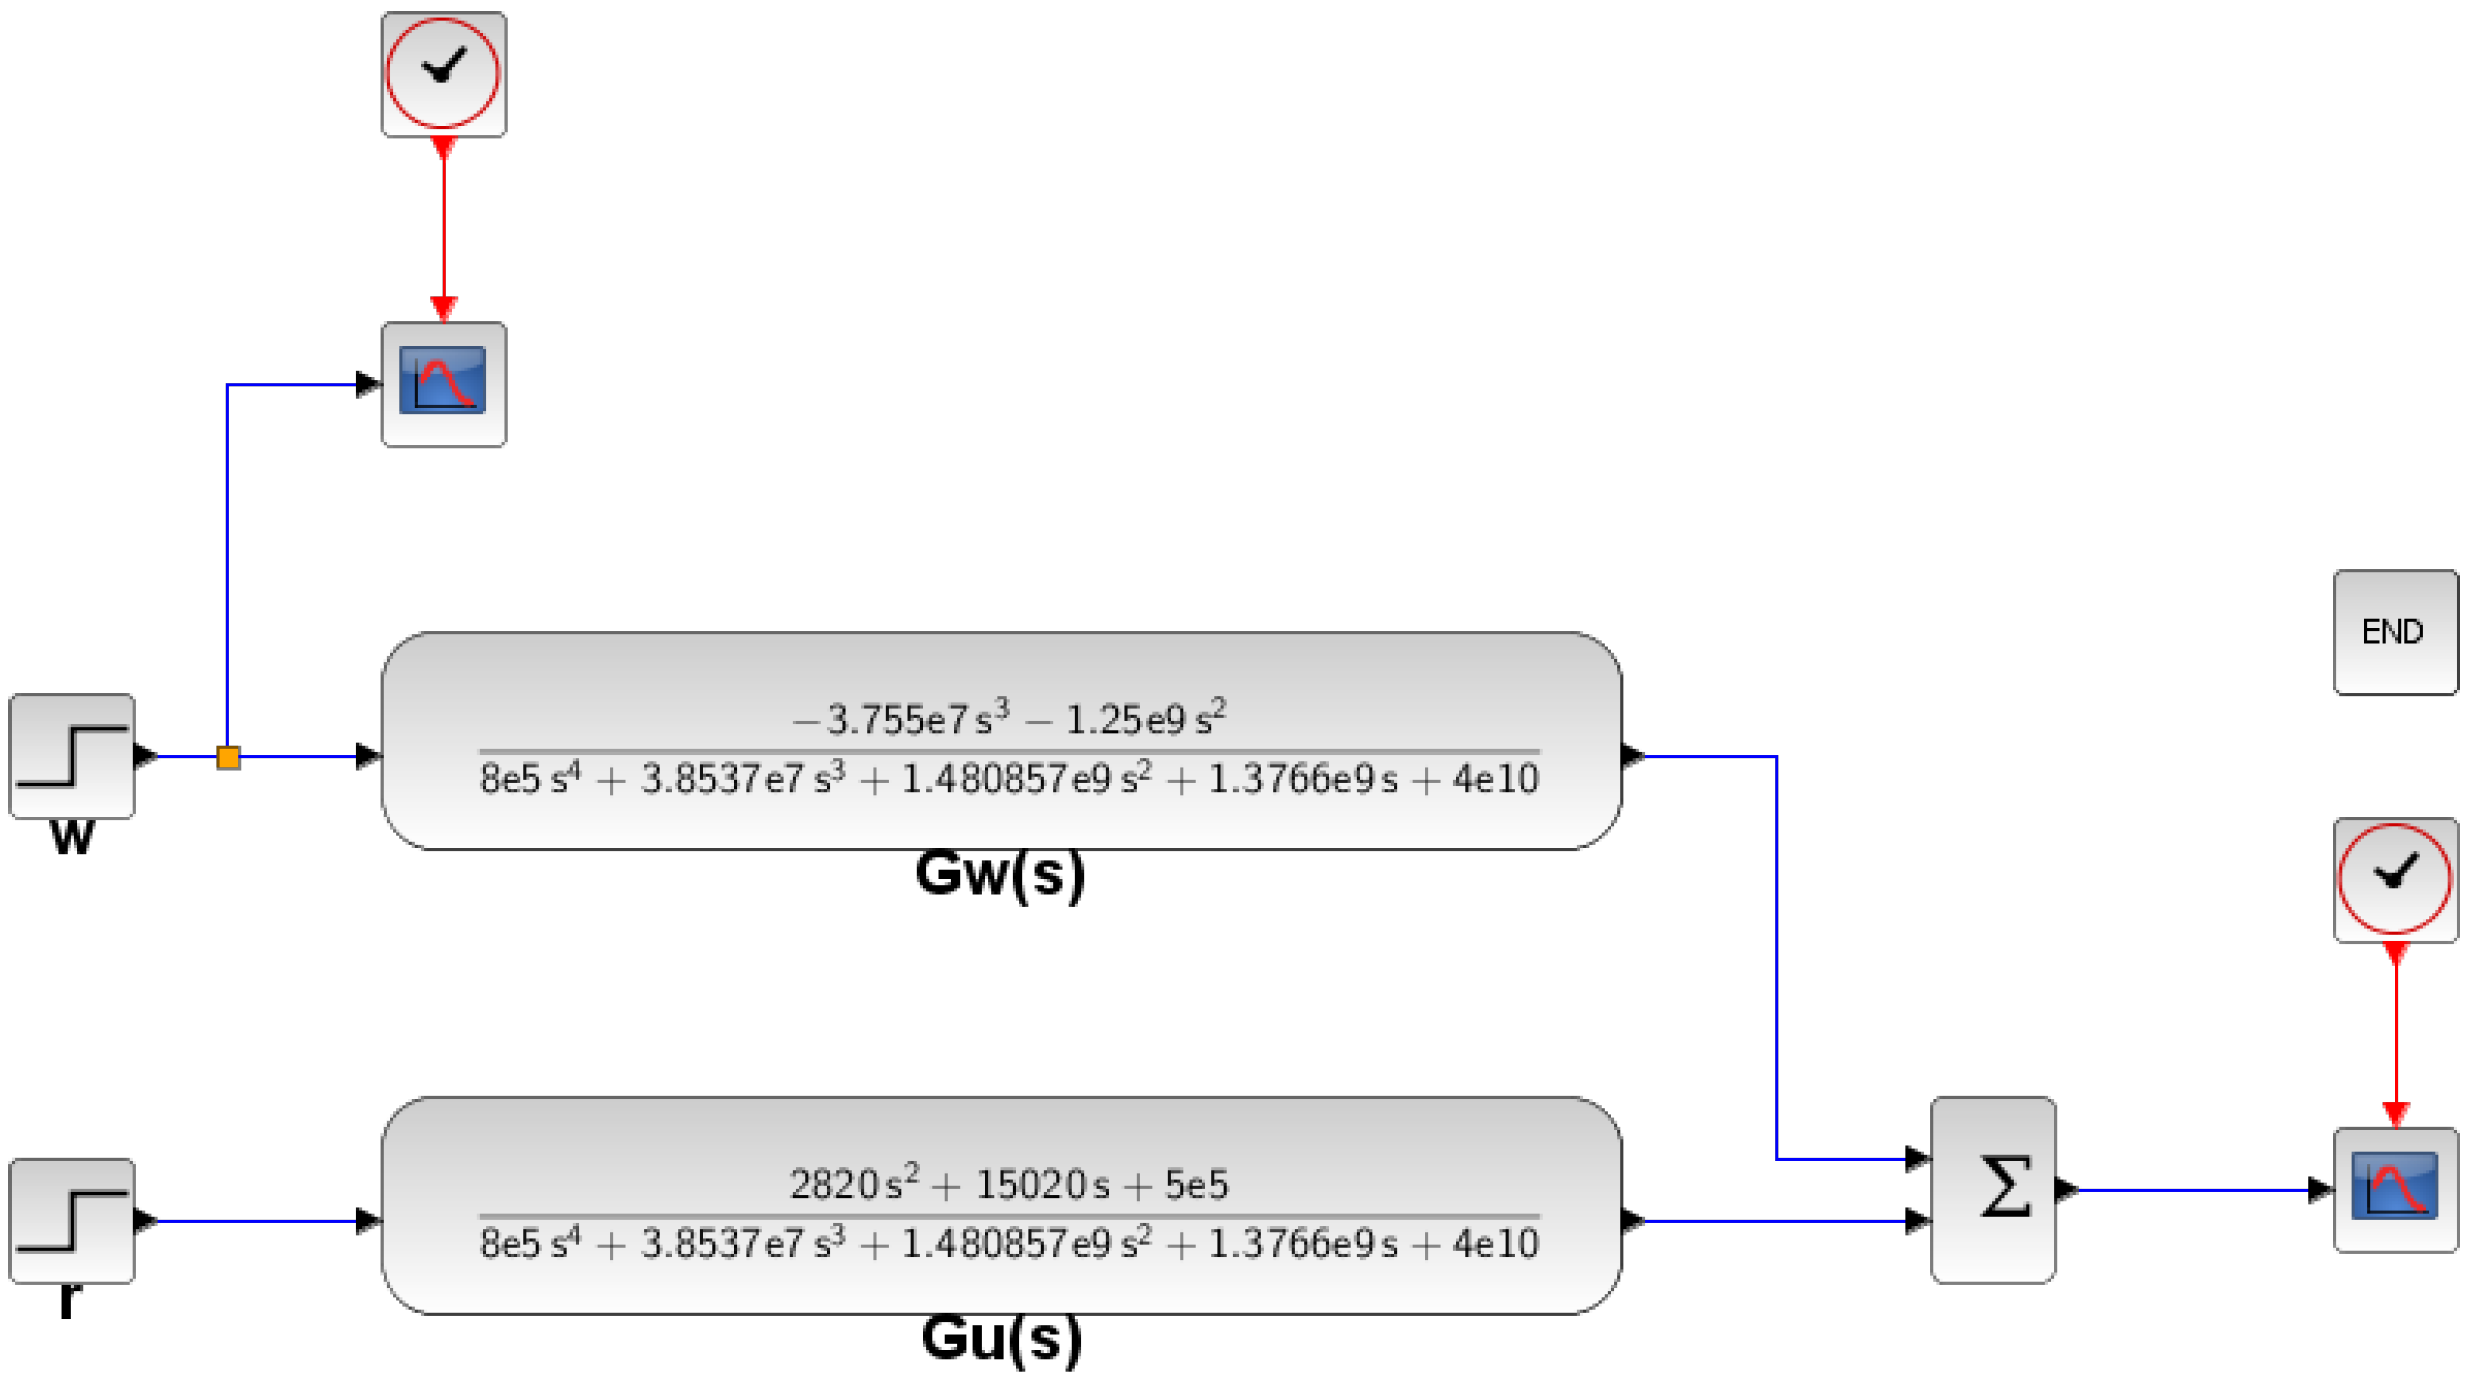

Valores encontrados nas atividades anteriores:

In [24]:
# Variável s
s = ct.TransferFunction.s

# G_w(s)
Gw = (-3.755e7*s**3 - 1.25e9*s**2) / (
    8e5*s**4 + 3.8537e7*s**3 + 1.480857e9*s**2 + 1.3766e9*s + 4e10
)

# G_u(s)
Gu = (2820*s**2 + 15020*s + 5e5) / (
    8e5*s**4 + 3.8537e7*s**3 + 1.480857e9*s**2 + 1.3766e9*s + 4e10
)

# C(s)
C = k*(T*s + 1) / (T*alpha*s + 1)
print(f"Compensador obtido:\n{C}")

Compensador obtido:
<TransferFunction>: sys[417]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  3.21e+05 s + 1.814e+08
  ----------------------
     0.0004412 s + 1


### Pertubação do tipo degrau

In [25]:
# Perturbação: degrau de 0.1 em t = 0.5 s
df = pd.read_csv("degrau.csv")
plot_resposta_sistema(df, Gw, Gu, C, titulo='Sistema compensado vs. não compensado <br> perturbação do tipo degrau')

### Perturbação do tipo degrau

A figura apresenta as respostas das suspensões compensada e não compensada a uma perturbação do tipo degrau, aplicada em aproximadamente t=0,5 s, com amplitude de 0,1 m.

Na suspensão não compensada, representada pela curva vermelha, a aplicação abrupta da perturbação provoca uma resposta oscilatória de amplitude elevada. No início, a deflexão atinge aproximadamente -0,1 m, seguida por picos positivos e negativos. A amplitude das oscilações diminui com o tempo, com decaimento lento, e o sistema comtinua apresentando oscilações significativas ao final do intervalo de 5 s. Isso mostra o baixo amortecimento dos modos dominantes da suspensão passiva.

O degrau possui componentes em uma ampla faixa de frequências, o que excita as frequências naturais da suspensão, explicando o as oscilações da resposta não compensada.

Por outro lado, a resposta da suspensão compensada, representada pela curva azul, permanece muito próxima de zero na escala apresentada. O controlador atenua basatante o efeito da perturbação, reduzindo o pico inicial e as próximas oscilações.

A variável de saída é definida por y(t) = x_1(t) - x_2(t), logo, o valor nulo em regime permanente é esperado. 

### Pertubação do tipo pulso

In [26]:
# Perturbação: pulso de 0.1, período de 32s, largura de pulso de 50%, atraso de 0.5s
df = pd.read_csv("pulso.csv")
plot_resposta_sistema(df, Gw, Gu, C, titulo='Sistema compensado vs. não compensado <br> perturbação do tipo pulso')

### Perturbação do tipo pulso

A figura apresenta as respostas das suspensões compensada e não compensada a uma perturbação do tipo pulso, com amplitude aproximada de 0,1 m. A entrada continua constante durante alguns intervalos e sofre transições abruptas entre 0 e 0,1 m.

A perturbação pode ser interpretada como uma sequência de degraus, ou seja, um degrau positivo no início de cada pulso e um degrau negativo no seu término. Cada uma dessas transições excita a dinâmica da suspensão, produzindo uma nova resposta transitória.

Na suspensão não compensada, representada pela curva vermelha, cada variação da entrada provoca oscilações de amplitude elevada. Logo após as transições, a deflexão alcança valores próximos de 0,1 a 0,12 m, apresentando em seguida oscilações amortecidas. Esse comportamento mostra que a suspensão passiva possui modos pouco amortecidos, que continuam influenciando a saída durante alguns segundos após cada mudança da perturbação.

A alternância do sinal dos picos está associada ao sentido da variação da entrada. Quando o pulso é aplicado, ocorre uma resposta transitória em um sentido e quando ele é retirado, a variação equivalente a um degrau negativo excita o sistema no sentido oposto. 

Por outro lado, a resposta da suspensão compensada, representada pela curva azul, permanece muito próxima de zero durante todo o intervalo analisado. Mesmo nos instantes em que a perturbação muda abruptamente, o controlador reduz de forma expressiva a deflexão da suspensão e praticamente elimina as oscilações observadas no sistema não compensado.

### Pertubação do tipo senoidal: pior caso da suspensão não-compensada

Nesse caso, a perturbação é do tipo senoidal, com frequência de 5,254 rad/s selecionada deliberadamente em razão de ser a perturbação que produz o pior desempenho da suspensão não compensada. Como discutido anteriormente, a resposta da suspensão não compensada depende essencialmente de Gw(s), cujo diagrama de Bode foi apresentado e discutido na Atividade 2, em que foi identificado um pico de 26,43 dB nessa frequência, indicando uma amplificação por um fator de 10^(26,43/20) ≈ 20,965. Além disso, a amplitude da entrada é de 0,1 m (valor de pico a pico de 0,2 m).

In [27]:
# Perturbação: senoide de amplitude 0.1 e frequencia de 5.254 rad/s (pior caso da suspensao nao compensada)
df = pd.read_csv("senoide_pior_caso_nao_compensado.csv")
plot_resposta_sistema(df, Gw, Gu, C, titulo='Sistema compensado vs. não compensado <br> perturbação do tipo senoidal (5.254 rad/s)')

### Perturbação senoidal na frequência de 5,254 rad/s

A resposta da suspensão não compensada apresenta uma amplificação da perturbação significativa. Embora a irregularidade da pista possua amplitude de aproximadamente 0,1 m, a deflexão da suspensão não compensada atinge valores próximos de 2 m ao final do intervalo analisado, o que corresponde a uma amplificação de aproximadamente vinte vezes em relação à amplitude da entrada.

O crescimento gradual da envoltória da resposta está associado ao período transitório do sistema. Como a frequência aplicada está próxima de uma região de ressonância e o sistema apresenta um baixo amortecimento, o regime permanente senoidal é atingido lentamente, com oscilações de amplitude baixa.

Por outro lado, a resposta da suspensão compensada permanece próxima de zero durante toda a simulação, apresentando amplitude muito inferior tanto à perturbação aplicada quanto à resposta do sistema não compensado. Dessa forma, o controlador reduz significativamente o efeito da irregularidade da pista sobre a deflexão da suspensão.

Além disso, a frequência de 5, rad/s está contida na faixa de passagem estimada para a suspensão passiva, onde as perturbações são pouco atenuadas pela parte passiva da suspensão, o que justifica a alta amplitude vista no sistema não compensado.

### Pertubação do tipo senoidal: pior caso da suspensão compensada

Novamente, a perturbação é do tipo senoidal, mas agora com frequência de 1205,7 rad/s selecionada deliberadamente em razão de ser a perturbação que produz o pior desempenho da suspensão compensada. Esse valor foi obtido do pico do diagrama de Bode de magnitude de $S(s)G_w(s)$ da Atividade 7. A amplitude da entrada é de 0,1 m (valor de pico a pico de 0,2 m).

In [28]:
# Perturbação: senoide de amplitude 0.1 e frequencia de 1205.7 rad/s (pior caso da suspensao compensada)
df = pd.read_csv("senoide_pior_caso_compensado.csv")
plot_resposta_sistema(df, Gw, Gu, C, titulo='Sistema compensado vs. não compensado <br> perturbação do tipo senoidal (1205.7 rad/s)')

### Perturbação senoidal na frequência de 1205,7 rad/s

Essa figura mostra a resposta da suspensão compensada e da suspensão não compensada para uma perturbação senoidal com frequência de aproximadamente 1205,7 rad/s, correspondente à frequência de maior ganho da função S(s)G_w(s).

Ambas as respostas apresentam amplitudes muito inferiores à amplitude da perturbação aplicada. Enquanto a irregularidade da pista possui amplitude de aproximadamente 0,1 m; a deflexão da suspensão permanece da ordem de poucos milímetros, o que indica uma alta atenuação da perturbação.

Além disso, as respostas dos sistemas compensado e não compensado são semelhantes. Em alguns instantes, a suspensão compensada apresenta amplitude um pouco maior com relação à suspensão não compensada, o que é um comportamento esperado por se tratar da frequência de pico da função. 

Outro ponto é que a frequência de 1205,7 rad/s se encontra acima da faixa de passagem estimada para a suspensão passiva, dessa forma, mesmo no pior caso para a suspensão compensada, a resposta permanece significativamente atenuada.